In [1]:
%load_ext autoreload

In [15]:
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import os
from JacobianODE.jacobians import TimeSeriesData
from JacobianODE.fnn import LSTMEmbedding, MLPEmbedding, FNN, compute_normalized_variances

**Computing the characeristic size of the attractor for the first $m$ latent coordinates**

From the paper, the characteristic size of the attractor when using the first $m$ latent coordinates is given by:


\begin{aligned}
\mathcal{R}^2_m &= \frac{1}{m B} \sum_{b=1}^B \sum_{i=1}^m (h_{bi} - \bar{h}_i)^2 \\
&= \frac{1}{m} \sum_{i=1}^m \left( \frac{1}{B} \sum_{b=1}^B (h_{bi} - \bar{h}_i)^2 \right) \\
&= \frac{1}{m} \sum_{i=1}^m \sigma_i^2
\end{aligned}
where $\sigma_i^2$ is the variance of the $i$-th coordinate over the batch.





In [3]:
curr_dir = os.getcwd()
data_dir = os.path.join(curr_dir, 'example_data')
os.makedirs(data_dir, exist_ok=True)
obs_noise = 0.01
file_path = os.path.join(data_dir, f'lorenz_data_obs_noise_{obs_noise}.npz')

print(f"Loading data from {file_path}")
custom_data = TimeSeriesData.load(file_path)
data = custom_data.values

Loading data from /orcd/home/002/eisenaj/code/JacobianODE/_jupyter/example_data/lorenz_data_obs_noise_0.01.npz


In [4]:
def compute_s_dim(Var_y_true, Var_y_estimated):
    """
    Computes the Dimension Similarity Score S_dim.
    
    Formula from Equation A12:
    S_dim = 1 - || SORT(Var(y)) - SORT(Var(y_hat)) || / || Var(y) ||
    """
    # Ensure both are sorted descending (SORT operation)
    v_true = np.sort(Var_y_true)[::-1]
    v_est = np.sort(Var_y_estimated)[::-1]
    
    # Ensure estimates are normalized by the same factor as the true system for fair comparison
    # (In practice, you'd normalize the estimate by its own max, 
    # but here we assume inputs are already effectively scaled/normalized variances)
    
    # Calculate L2 Norm of the difference (Numerator)
    numerator = np.linalg.norm(v_true - v_est)
    
    # Calculate L2 Norm of the true variances (Denominator)
    denominator = np.linalg.norm(v_true)
    
    # Calculate S_dim
    s_dim = 1 - (numerator / denominator)
    
    return s_dim

In [16]:
# Sweep FNN regularization weight
from JacobianODE.fnn import MLPEmbedding, FNN, compute_normalized_variances

lambda_values = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
# train_data = data[:24, :, [0]]
# test_data = data[24:, :, [0]]
train_data = data[:4, :, [0]]
test_data = data[4:8, :, [0]]

results = {
    "lambda": [],
    "model": [],
    "mse": [],
    "norm_var": [],
    "s_dim": [],
}

# True normalized variances (pad to n_latent dims with zeros)
n_latent = 10
true_padded = np.concatenate(
    (data, np.zeros((data.shape[0], data.shape[1], n_latent - data.shape[2]))), axis=2
)
norm_var_true = compute_normalized_variances(true_padded.reshape(-1, n_latent))

for lam in lambda_values:
    print(f"Training with lambda={lam} ...")
    reg = FNN(lam) if lam > 0 else None
    # model = MLPEmbedding(
    model = LSTMEmbedding(
        n_latent=n_latent, time_window=100,
        network_shape=[10], latent_regularizer=reg,
    )
    model.fit(train_data, train_steps=200, verbose=0)

    # Reconstruction MSE
    X_windows, recon = model.reconstruct(test_data)
    mse = ((X_windows - recon) ** 2).mean()

    # Normalized variances & S_dim
    enc_data = model.transform(test_data)
    norm_var_est = compute_normalized_variances(enc_data.reshape(-1, n_latent))
    s_dim = compute_s_dim(norm_var_true, norm_var_est)

    results["lambda"].append(lam)
    results["model"].append(model)
    results["mse"].append(mse)
    results["norm_var"].append(norm_var_est)
    results["s_dim"].append(s_dim)

    print(f"  MSE={mse:.6f}, S_dim={s_dim:.4f}")

print("Done.")

Training with lambda=0 ...
  MSE=0.330547, S_dim=0.4694
Training with lambda=1e-06 ...
  MSE=0.333192, S_dim=0.4381
Training with lambda=1e-05 ...
  MSE=0.352587, S_dim=0.2735
Training with lambda=0.0001 ...
  MSE=0.281530, S_dim=0.2405
Training with lambda=0.001 ...
  MSE=0.330897, S_dim=0.5569
Training with lambda=0.01 ...
  MSE=0.284872, S_dim=0.7505
Training with lambda=0.1 ...
  MSE=0.423617, S_dim=0.6857
Training with lambda=1 ...
  MSE=0.386916, S_dim=0.6857
Training with lambda=10 ...
  MSE=0.468666, S_dim=0.6857
Done.


In [17]:
[np.sum(vars) for vars in results["norm_var"]]

[np.float64(2.3948509111232426),
 np.float64(2.4115227928850156),
 np.float64(2.909558169275584),
 np.float64(2.7647080300832796),
 np.float64(2.2533807488210886),
 np.float64(1.708168986304587),
 np.float64(1.0000000006887872),
 np.float64(1.000000000169723),
 np.float64(1.000000883668772)]

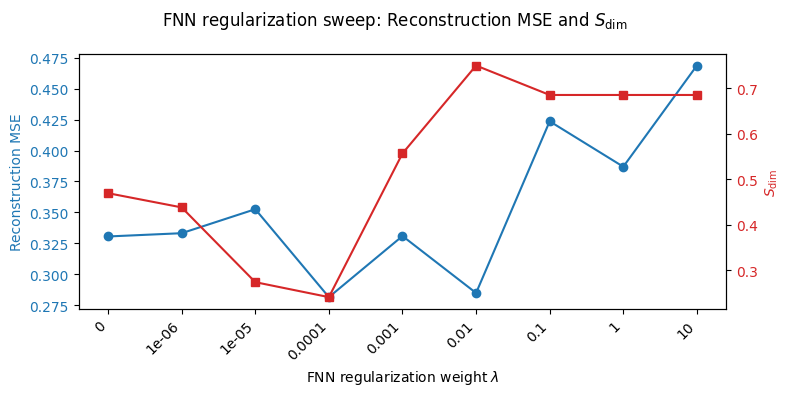

In [18]:
# --- Plot S_dim and Reconstruction MSE vs lambda ---
fig, ax1 = plt.subplots(figsize=(8, 4))

x_labels = [str(v) for v in results["lambda"]]
x_pos = np.arange(len(x_labels))

color_mse = "tab:blue"
ax1.set_xlabel(r"FNN regularization weight $\lambda$")
ax1.set_ylabel("Reconstruction MSE", color=color_mse)
ax1.plot(x_pos, results["mse"], "o-", color=color_mse, label="Recon MSE")
ax1.tick_params(axis="y", labelcolor=color_mse)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, rotation=45, ha="right")

ax2 = ax1.twinx()
color_sdim = "tab:red"
ax2.set_ylabel(r"$S_{\mathrm{dim}}$", color=color_sdim)
ax2.plot(x_pos, results["s_dim"], "s-", color=color_sdim, label=r"$S_{\mathrm{dim}}$")
ax2.tick_params(axis="y", labelcolor=color_sdim)

fig.suptitle(r"FNN regularization sweep: Reconstruction MSE and $S_{\mathrm{dim}}$")
fig.tight_layout()
plt.show()

In [19]:
results["norm_var"][5]

array([1.00000000e+00, 5.85258890e-01, 8.70509859e-02, 1.91954386e-02,
       1.46034867e-02, 1.23815394e-03, 4.83191129e-04, 2.54694454e-04,
       7.64835181e-05, 7.66248516e-06])

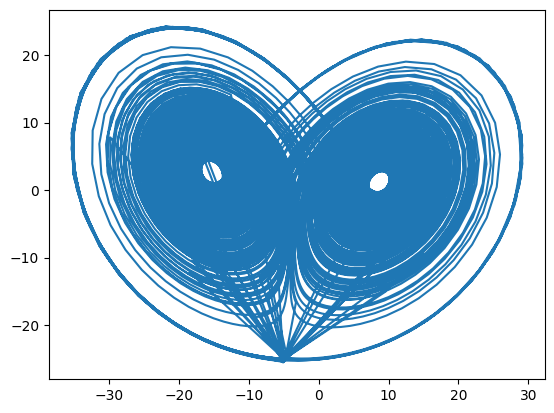

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
true_data_pca = pca.fit_transform(data.reshape(-1, data.shape[2]))
plt.plot(true_data_pca[:, 0], true_data_pca[:, 1])

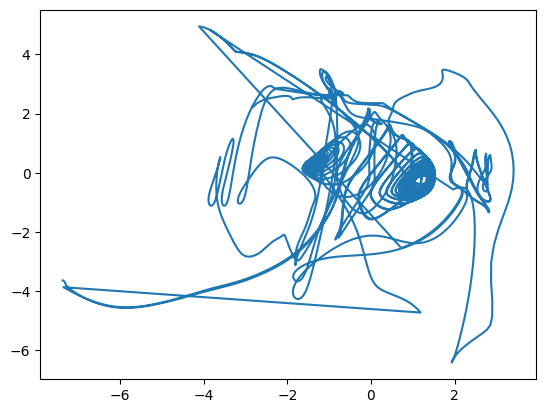

In [21]:



enc_data = results["model"][5].transform(train_data)
pca = PCA(n_components=n_latent)
enc_data_pca = pca.fit_transform(enc_data.reshape(-1, n_latent))

plt.plot(enc_data_pca[:, 0], enc_data_pca[:, 1])

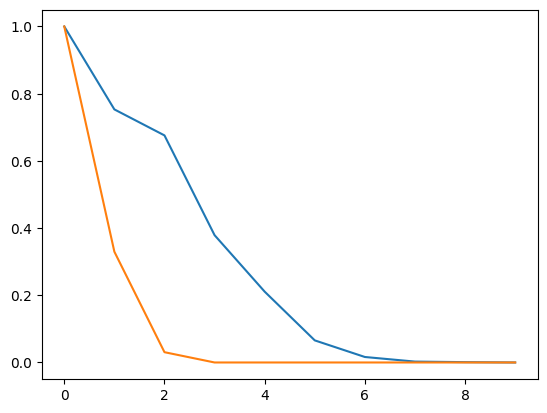

In [11]:
plt.plot(results["norm_var"][1])
plt.plot(norm_var_true)